## FEATURE ENGINEERING 
Is the process of using domain knowledge to select, create, or transform raw data into meaningful features (input variables) that make machine learning models work more effectively.
Here we perform variuos operatiosn like feature transformation(missing value handling, outlier treatment, handeling categorical data, scaling), feature construction, feature selection, feature extraction

## Feature transformation

In [3]:
import numpy as np
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('Housing.csv')

In [5]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### Scaling
Machine learning models learn from numerical features, and features with larger magnitudes can disproportionately influence the model’s decisions. To prevent any single feature from dominating due to its scale, we apply scaling techniques. Scaling transforms all feature values to a similar range or magnitude, ensuring that each feature contributes fairly to the model’s performance.

In [21]:
X=df[['area']]
y=df['price']

#### Here we will use Standard scaling as we have variuos types of scaling available like min-max scaling,

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,y, test_size=0.25,random_state=42)

In [23]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)

In [24]:
X_train

,area
167,4600
368,5640
301,3520
527,1836
382,3150
...,...
71,6000
106,5450
270,4500
435,4040


In [25]:
X_train_scaled

array([[-2.49346791e-01],
       [ 2.22626972e-01],
       [-7.39473390e-01],
       [-1.50370783e+00],
       [-9.07387132e-01],
       [ 2.40779809e-01],
       [-1.36347716e+00],
       [ 1.33902645e+00],
       [-5.53406811e-01],
       [ 5.76607293e-01],
       [-4.62642626e-01],
       [ 2.85478834e+00],
       [ 2.05016384e+00],
       [ 2.36466174e+00],
       [ 3.67849668e-01],
       [-1.02991878e+00],
       [ 5.49378038e-01],
       [-7.57626227e-01],
       [ 1.33902645e+00],
       [ 6.31065804e-01],
       [-1.07212413e+00],
       [ 6.03836549e-01],
       [-7.03167716e-01],
       [-8.91503400e-01],
       [-3.35572767e-01],
       [ 1.74746528e+00],
       [-6.80476670e-01],
       [ 9.12434778e-01],
       [-7.10428851e-01],
       [-3.94569487e-01],
       [ 8.39823430e-01],
       [ 2.02883425e+00],
       [ 1.82279955e+00],
       [-1.35666985e+00],
       [ 4.08693551e-01],
       [ 1.74746528e+00],
       [ 7.74042754e-02],
       [ 1.65670110e+00],
       [ 1.5

## Outlier treatment

A data point, person, or thing that differs significantly from the rest of a dataset or group, lying far outside the overall pattern

Outliers can significantly degrade model performance by biasing parameter estimates, distorting the underlying data distribution, and causing the model to overfit to noise rather than true patterns.

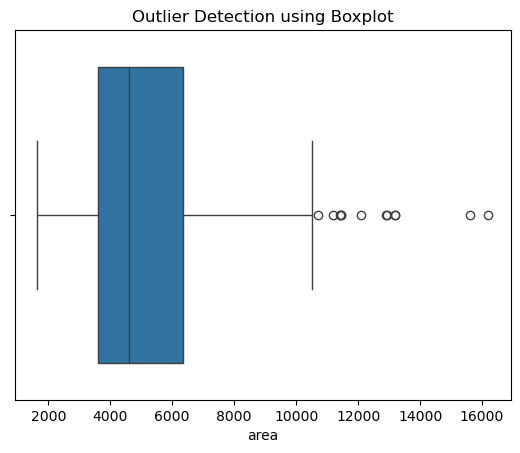

In [26]:
sns.boxplot(x=df['area'])
plt.title("Outlier Detection using Boxplot")
plt.show()

In [27]:
Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df_clean = df[(df['area'] >= lower_bound) & (df['area'] <= upper_bound)]

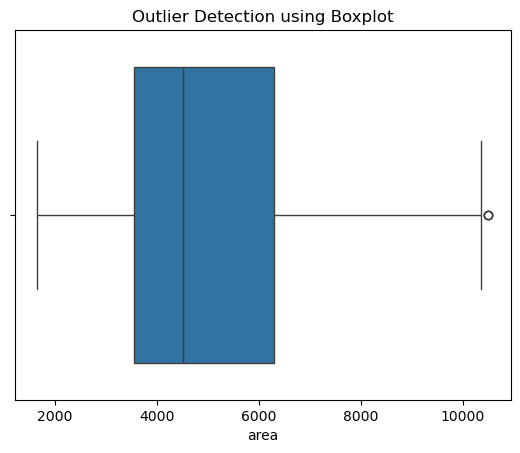

In [28]:
sns.boxplot(x=df_clean['area'])
plt.title("Outlier Detection using Boxplot")
plt.show()

## Null value treatment

We can treat null values by replacing the null values from the dataset by mean, mode and by using knn imputer

In [31]:
df2=pd.read_csv("patients.csv")

In [32]:
df2.head()

,Gender,age,education,currentSmoker,cigsPerDay,BP Meds,prevalentStroke,prevalentHyp,diabetes,tot cholesterol,Systolic BP,Diastolic BP,BMI,heartRate,glucose,Heart-Att
0,Male,39.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,Female,46.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,Male,48.0,1.0,1.0,20.0,0.0,0.0,0.0,0.0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,Female,61.0,3.0,1.0,30.0,0.0,0.0,1.0,0.0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,Female,46.0,3.0,1.0,23.0,0.0,0.0,0.0,0.0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [35]:
df2.isnull().sum()

Gender               8
age                  2
education          110
currentSmoker        3
cigsPerDay          31
BP Meds             60
prevalentStroke      9
prevalentHyp         2
diabetes             2
tot cholesterol     60
Systolic BP          4
Diastolic BP         5
BMI                 24
heartRate            4
glucose            391
Heart-Att            0
dtype: int64

#### Replacing null value with mean

In [37]:
df2['age']=df2['age'].fillna(df2['age'].mean())

In [38]:
df2['age'].isnull().sum()

np.int64(0)

Now we can see that there are no null values in age.

#### Replacing null value with mode

In [43]:
df2['Gender']=df2['Gender'].fillna(df2['Gender'].mode())

In [45]:
df2['Gender'].isnull().sum()

np.int64(8)

Now we can see that there are no null values in Gender

#### Replacing null values using knn imputer

In [52]:
from sklearn.impute import KNNImputer
imputer=KNNImputer(n_neighbors=2)
df2['glucose']=imputer.fit_transform(df2[['glucose']])

In [53]:
df2['glucose'].isnull().sum()

np.int64(0)

In [ ]:
Now we can see that there are no null values in Gender